### Importing pandas and loading the df

In [1]:
import pandas as pd
df= pd.read_csv("sample.csv")

In [2]:
# Loading NRC lexicon
nrc_df = pd.read_csv(
    "https://raw.githubusercontent.com/dinbav/LeXmo/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
    sep='\t', header=None, names=['word', 'emotion', 'association']
)
nrc_df = nrc_df[nrc_df['association'] == 1]  # only positive associations
nrc_dict = nrc_df.groupby('word')['emotion'].apply(list).to_dict()

print(f"NRC lexicon loaded: {len(nrc_dict)} words")



NRC lexicon loaded: 6468 words


In [3]:
# Scoring function
def get_emotion_scores(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}
    words = text.lower().split()
    counts = {}
    for word in words:
        if word in nrc_dict:
            for emotion in nrc_dict[word]:
                counts[emotion] = counts.get(emotion, 0) + 1
    total = len(words)
    return {k: v / total for k, v in counts.items()}

In [4]:

# Applying the function to the df
df["emotion_scores"] = df["article_text"].apply(get_emotion_scores)

# ── 4. Expand dict into clean columns ────────────────────────────────────
emotion_df = df["emotion_scores"].apply(pd.Series).fillna(0)
df = pd.concat([df, emotion_df], axis=1)
df.drop(columns=["emotion_scores"], inplace=True)


In [5]:
df.head(20)

,id,primary_country,country_freq,article_text,anger,fear,negative,sadness,surprise,anticipation,positive,trust,disgust,joy
0,3deecee02dba9cb11c3dda429f4f3181696915f1,US,"{'US': 4, 'NZ': 2, 'WS': 3, 'AS': 1, 'TO': 1}",(CNN) -- When an earthquake threatens to turn ...,0.013850,0.035088,0.023084,0.009234,0.011080,0.017544,0.048938,0.025854,0.004617,0.005540
1,c327a45bce74b6e46e2b8e26c7c358dc5d211133,ID,"{'ID': 12, 'NO': 4}",(CNN) -- One of the world's largest pulp and p...,0.013208,0.013208,0.022642,0.007547,0.003774,0.015094,0.033962,0.013208,0.001887,0.003774
2,0c583c71f1ceddb9569f6d8588f62108ca645b91,KP,"{'KP': 4, 'CN': 3}","(CNN) -- Kim Jong Un, successor to his father'...",0.008876,0.019231,0.026627,0.013314,0.013314,0.025148,0.038462,0.028107,0.008876,0.005917
3,f7ef47b6d6d9963c4801bb0c472629238a38740b,IQ,{'IQ': 12},Baghdad (CNN) -- At least 16 people were kille...,0.032941,0.049412,0.056471,0.030588,0.014118,0.014118,0.044706,0.035294,0.018824,0.009412
4,e439517292eaeab7ffead2af6ba826017b2d2f61,CU,{'CU': 2},Atlanta (CNN) -- Former U.S. President Jimmy C...,0.008475,0.004237,0.012712,0.008475,0.004237,0.029661,0.076271,0.038136,0.004237,0.008475
5,4d0dc17c4ad398906ac103f476d9355f169a7d87,US,"{'US': 5, 'AU': 1, 'BS': 1}",(CNN) -- New York's famous skyline may be gett...,0.000000,0.003650,0.000000,0.000000,0.003650,0.021898,0.058394,0.007299,0.000000,0.007299
6,cf9840f55e863768468593d034a8d2e8b60f2a3c,GB,"{'IE': 4, 'GB': 6, 'IT': 3, 'FR': 2}",Ireland kept alive their Six Nations champions...,0.003344,0.003344,0.020067,0.010033,0.010033,0.020067,0.030100,0.020067,0.000000,0.020067
7,3a00cfd7ef02b9e00ca88fc42ce732fae239c419,US,{'US': 1},(CNN) -- A Massachusetts grand jury has indict...,0.022305,0.029740,0.018587,0.014870,0.011152,0.011152,0.037175,0.040892,0.026022,0.014870
8,a89edbfe9c26f5f423d9448eda6e1e9bcb4dabf0,AF,"{'AF': 1, 'GB': 1, 'DE': 1}","(CNN) -- ""Call of Duty: Modern Warfare 3"" cont...",0.021875,0.025000,0.037500,0.014063,0.007812,0.020313,0.043750,0.032813,0.012500,0.017188
9,0722eb694b993eb3731c1237ac89ce09aa46948c,US,{'US': 1},(CNN) -- Time is running out for congressional...,0.012270,0.034765,0.040900,0.028630,0.010225,0.028630,0.049080,0.040900,0.010225,0.020450


In [6]:
df.describe()

,anger,fear,negative,sadness,surprise,anticipation,positive,trust,disgust,joy
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.014507,0.022108,0.028590,0.013513,0.008678,0.018701,0.045686,0.031333,0.007788,0.013520
std,0.011195,0.015604,0.014903,0.008641,0.005481,0.008354,0.014359,0.013387,0.006192,0.008134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015152,0.000000,0.000000,0.000000
25%,0.006050,0.009875,0.017328,0.007411,0.004830,0.012909,0.036053,0.022326,0.003054,0.007851
50%,0.012289,0.017674,0.026730,0.011888,0.008002,0.017773,0.043644,0.029606,0.006553,0.012768
75%,0.020026,0.031270,0.037675,0.018368,0.011380,0.023388,0.053836,0.038246,0.011171,0.017917
max,0.054018,0.082677,0.074766,0.040959,0.026906,0.053512,0.096154,0.073684,0.040959,0.058496


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               250 non-null    object 
 1   primary_country  226 non-null    object 
 2   country_freq     250 non-null    object 
 3   article_text     250 non-null    object 
 4   anger            250 non-null    float64
 5   fear             250 non-null    float64
 6   negative         250 non-null    float64
 7   sadness          250 non-null    float64
 8   surprise         250 non-null    float64
 9   anticipation     250 non-null    float64
 10  positive         250 non-null    float64
 11  trust            250 non-null    float64
 12  disgust          250 non-null    float64
 13  joy              250 non-null    float64
dtypes: float64(10), object(4)
memory usage: 27.5+ KB


In [8]:
df.head(1)

,id,primary_country,country_freq,article_text,anger,fear,negative,sadness,surprise,anticipation,positive,trust,disgust,joy
0,3deecee02dba9cb11c3dda429f4f3181696915f1,US,"{'US': 4, 'NZ': 2, 'WS': 3, 'AS': 1, 'TO': 1}",(CNN) -- When an earthquake threatens to turn ...,0.01385,0.035088,0.023084,0.009234,0.01108,0.017544,0.048938,0.025854,0.004617,0.00554


### Labelling check

In [9]:
# Check highest fear article
most_fear_idx = df['fear'].idxmax()
print(f"Fear score: {df.loc[most_fear_idx, 'fear']:.4f}")
print(f"Country: {df.loc[most_fear_idx, 'primary_country']}")
print()
print(df.loc[most_fear_idx, 'article_text'][:500])  # first 500 chars

Fear score: 0.0827
Country: US

New Orleans, Louisiana (CNN) -- Four New Orleans police officers accused of killing two men after Hurricane Katrina are scheduled to appear in federal courtrooms Friday. The officers are charged with multiple counts of conspiracy, weapons and civil rights violations in connection with the well-publicized 2005 shootings in the infamous Danziger Bridge incident. The hearings Friday will determine whether the officers will be held in jail until the trial, according to court documents. Three of the 


In [10]:
for emotion in ['anger', 'joy', 'trust', 'sadness']:
    idx = df[emotion].idxmax()
    print(f"\n── Highest {emotion.upper()} (score: {df.loc[idx, emotion]:.4f}) ──")
    print(df.loc[idx, 'article_text'][:300])
    print()


── Highest ANGER (score: 0.0540) ──
(CNN) -- When most Americans think about heroic efforts that save lives and keep communities safe from gun violence, I suspect they picture someone with a badge, gun or bullet-proof vest who, with similarly equipped colleagues, busts down doors in pursuit of criminal thugs. I salute the fine officer


── Highest JOY (score: 0.0585) ──
(CNN) -- Somali gunmen on Wednesday released a British aid worker kidnapped last week while working for Save the Children. The aid worker, named as Zimbabwe-born Frans Barnard, was freed after tribal elders negotiated with his captors, Save the Children confirmed. Barnard was safe and well and had b


── Highest TRUST (score: 0.0737) ──
(CNN) -- Administrative Professionals Week is coming to a close, and though the term "secretary" is fraught with negative meaning for some, there have been stellar examples of efficiency, smarts and loyalty shown by administrative assistants both in real life and on the silver screen th

In [11]:
def explain_emotion_scores(text, nrc_dict):
    words = text.lower().split()
    matches = {}
    for word in words:
        if word in nrc_dict:
            for emotion in nrc_dict[word]:
                if emotion not in matches:
                    matches[emotion] = []
                matches[emotion].append(word)
    return matches

# Inspect a specific article
idx = 0  # change this to any row
matches = explain_emotion_scores(df.loc[idx, 'article_text'], nrc_dict)

for emotion, words in matches.items():
    print(f"{emotion:15s}: {words[:10]}")  # show up to 10 trigger words


anger          : ['earthquake', 'fits', 'frenetic', 'disaster', 'earthquake', 'earthquake', 'delay', 'caution', 'interrupt', 'strike']
fear           : ['earthquake', 'warning', 'warning', 'warning', 'warning', 'evacuate', 'frenetic', 'warning', 'disaster', 'warning']
negative       : ['earthquake', 'wait', 'fits', 'evacuate', 'tragic', 'frenetic', 'disaster', 'earthquake', 'earthquake', 'delay']
sadness        : ['earthquake', 'disaster', 'earthquake', 'earthquake', 'delay', 'disaster', 'earthquake', 'case', 'feeling', 'feeling']
surprise       : ['earthquake', 'frenetic', 'disaster', 'earthquake', 'earthquake', 'interrupt', 'lucky', 'disaster', 'earthquake', 'feeling']
anticipation   : ['wait', 'thought', 'time', 'time', 'time', 'result', 'caution', 'time', 'time', 'scientist']
positive       : ['pacific', 'center', 'job', 'director', 'coast', 'coast', 'pacific', 'center', 'pacific', 'sea']
trust          : ['center', 'director', 'center', 'director', 'center', 'real', 'center', 'ope

### Moral Foundations Theory lexicon

### A bit of an explanantion on the model and the lexicon itself:
5 universal foundations
- Vice vs Virtue (negative vs positve quality)

1. Care (Vice: Harm)
2. Fairness (Vice:Cheating)
3. Loyalty (Vice: Betrayal)
4. Authority (Vice: Subversion)
5. Sanctity (Vice: Degradation)


In [12]:
import re

def parse_wmodel(filepath):
    """
    Parse the .wmodel MFD file format:
    [CATEGORIZATION]
    CARE.VIRTUE          <- category header (no tab)
        WORD (1)         <- word entry (has tab)
    """
    word_to_foundation = {}
    current_category = None
    in_categorization = False

    # Known MFD categories to look for
    mfd_categories = [
        'CARE.VIRTUE', 'CARE.VICE',
        'FAIRNESS.VIRTUE', 'FAIRNESS.VICE',
        'LOYALTY.VIRTUE', 'LOYALTY.VICE',
        'AUTHORITY.VIRTUE', 'AUTHORITY.VICE',
        'SANCTITY.VIRTUE', 'SANCTITY.VICE'
    ]

    with open(filepath, 'r', encoding='utf-8-sig', errors='ignore') as f:
        for line in f:
            line = line.rstrip('\r\n')

            # Enter categorization section
            if line.strip() == '[CATEGORIZATION]':
                in_categorization = True
                continue

            # Exit categorization section
            if in_categorization and line.startswith('[') and line.strip() != '[CATEGORIZATION]':
                in_categorization = False
                continue

            if not in_categorization:
                continue

            # Category header — no leading tab, matches known MFD category
            if not line.startswith('\t') and line.strip() in mfd_categories:
                current_category = line.strip().lower()  # e.g. 'care.virtue'
                continue

            # Word entry — has leading tab
            if line.startswith('\t') and current_category:
                # Format: "\tWORD (1)"  ->  extract just the word
                word = line.strip().split('(')[0].strip().lower()
                if word:
                    word_to_foundation[word] = current_category

    return word_to_foundation

# Load it
# Mac example
word_to_foundation = parse_wmodel("Moral Foundations Dictionary.wmodel 2")

print(f"Loaded: {len(word_to_foundation)} words")
print(f"\nCategories: {set(word_to_foundation.values())}")
print(f"\nSample words per category:")
import pandas as pd
sample_df = pd.DataFrame(list(word_to_foundation.items()), columns=['word', 'foundation'])
for cat, grp in sample_df.groupby('foundation'):
    print(f"  {cat:25s}: {list(grp['word'])[:5]}")

Loaded: 2041 words

Categories: {'loyalty.virtue', 'authority.vice', 'sanctity.vice', 'fairness.vice', 'authority.virtue', 'care.virtue', 'fairness.virtue', 'loyalty.vice', 'sanctity.virtue', 'care.vice'}

Sample words per category:
  authority.vice           : ['rebel', 'rebellion', 'rebellions', 'rebels', 'treacherous']
  authority.virtue         : ['protect', 'protected', 'protecting', 'protection', 'protector']
  care.vice                : ['vulnerability', 'vulnerable', 'wound', 'wounded', 'wounding']
  care.virtue              : ['alleviate', 'alleviated', 'alleviates', 'alleviating', 'alleviation']
  fairness.vice            : ['exploit', 'exploitation', 'exploited', 'exploiter', 'exploiters']
  fairness.virtue          : ['avenge', 'avenged', 'avenger', 'avengers', 'avenges']
  loyalty.vice             : ['betray', 'betrayed', 'betrayer', 'betrayers', 'betraying']
  loyalty.virtue           : ['all_for_one', 'allied', 'allies', 'ally', 'belong']
  sanctity.vice            : ['a

### Defining a function and applying it on the sample

In [13]:
mfd2_categories = [
    'care.virtue', 'care.vice',
    'fairness.virtue', 'fairness.vice',
    'loyalty.virtue', 'loyalty.vice',
    'authority.virtue', 'authority.vice',
    'sanctity.virtue', 'sanctity.vice'  
]

# Words to remove from the lexicon — clear false triggers
noise_words = {
    # loyalty.virtue proper nouns / neutral collectives
    'united', 'country', 'nations', 'company', 'war',
    'group', 'groups', 'organization', 'countries',
    
    # authority.virtue neutral institutional refs
    'police', 'president', 'presidents', 'father',
    'arrested', 'arrest', 'controlled', 'control',
    
    # sanctity.virtue overly generic
    'food', 'body', 'blood', 'clean',
    
    # fairness.virtue legal procedure not moral fairness
    'lawyer', 'lawyers', 'law', 'laws', 'referee'
}

# Remove them
for word in noise_words:
    if word in word_to_foundation:
        del word_to_foundation[word]

print(f"Lexicon after cleaning: {len(word_to_foundation)} words")

def get_mfd2_scores(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {cat: 0.0 for cat in mfd2_categories}
    words = text.lower().split()
    counts = {cat: 0 for cat in mfd2_categories}
    for word in words:
        clean_word = re.sub(r'[^a-z]', '', word)
        if clean_word in word_to_foundation:
            foundation = word_to_foundation[clean_word]
            if foundation in counts:
                counts[foundation] += 1
    total = len(words)
    return {k: v / total for k, v in counts.items()}

# Apply to dataframe
df["mfd2_scores"] = df["article_text"].apply(get_mfd2_scores)
mfd2_df = df["mfd2_scores"].apply(pd.Series).fillna(0)
df = pd.concat([df, mfd2_df], axis=1)
df.drop(columns=["mfd2_scores"], inplace=True)

print(df[mfd2_categories].describe())

Lexicon after cleaning: 2015 words
       care.virtue   care.vice  fairness.virtue  fairness.vice  \
count   250.000000  250.000000       250.000000     250.000000   
mean      0.004566    0.005824         0.001191       0.000549   
std       0.006351    0.008585         0.002559       0.001817   
min       0.000000    0.000000         0.000000       0.000000   
25%       0.000000    0.000000         0.000000       0.000000   
50%       0.002584    0.002532         0.000000       0.000000   
75%       0.005881    0.007146         0.001226       0.000000   
max       0.047674    0.049180         0.016556       0.018293   

       loyalty.virtue  loyalty.vice  authority.virtue  authority.vice  \
count      250.000000    250.000000        250.000000      250.000000   
mean         0.003852      0.000057          0.004733        0.000630   
std          0.005295      0.000382          0.004567        0.001447   
min          0.000000      0.000000          0.000000        0.000000   
25%  

In [14]:
# Checking the word triggers
def explain_mfd2(text, word_to_foundation):
    words = text.lower().split()
    matches = {}
    for word in words:
        clean = re.sub(r'[^a-z]', '', word)
        if clean in word_to_foundation:
            foundation = word_to_foundation[clean]
            matches.setdefault(foundation, []).append(clean)
    return matches

# Inspect one article
idx = 0
matches = explain_mfd2(df.loc[idx, 'article_text'], word_to_foundation)
for foundation, words in matches.items():
    print(f"{foundation:25s}: {words[:8]}")

care.vice                : ['threatens', 'threat', 'killed']
authority.virtue         : ['duty']
loyalty.virtue           : ['wife', 'family']
care.virtue              : ['love']


In [15]:
from collections import Counter

def get_all_triggers(df, word_to_foundation):
    """Count how often each matched word appears across all articles"""
    all_matches = {cat: Counter() for cat in mfd2_categories}
    
    for text in df['article_text']:
        if not isinstance(text, str):
            continue
        words = text.lower().split()
        for word in words:
            clean = re.sub(r'[^a-z]', '', word)
            if clean in word_to_foundation:
                foundation = word_to_foundation[clean]
                all_matches[foundation][clean] += 1
    
    return all_matches

all_triggers = get_all_triggers(df, word_to_foundation)

# Print top 15 trigger words per category
for cat in mfd2_categories:
    top_words = all_triggers[cat].most_common(15)
    print(f"\n── {cat.upper()} ──")
    print(top_words)


── CARE.VIRTUE ──
[('health', 94), ('help', 77), ('care', 67), ('love', 44), ('child', 36), ('hospital', 32), ('mother', 32), ('safe', 27), ('safety', 23), ('share', 21), ('helped', 18), ('shared', 12), ('healthy', 12), ('empathy', 12), ('patient', 9)]

── CARE.VICE ──
[('killed', 65), ('violence', 60), ('attack', 47), ('attacks', 44), ('violent', 36), ('victims', 35), ('fighting', 27), ('injured', 24), ('killing', 23), ('fight', 21), ('murder', 19), ('kill', 19), ('suffering', 19), ('assault', 17), ('damage', 16)]

── FAIRNESS.VIRTUE ──
[('rights', 74), ('justice', 28), ('fair', 12), ('honest', 9), ('trust', 8), ('integrity', 7), ('compensation', 6), ('equals', 3), ('justices', 2), ('equal', 2), ('lawfully', 2), ('trusted', 2), ('honesty', 2), ('referees', 2), ('justify', 1)]

── FAIRNESS.VICE ──
[('stolen', 10), ('prejudice', 7), ('fraud', 5), ('betrayal', 4), ('misleading', 4), ('discrimination', 4), ('bias', 4), ('stole', 4), ('disparity', 3), ('steal', 3), ('unjust', 3), ('exploi

In [16]:
import random

def manual_check_sample(df, category, word_to_foundation, n=10, high=True):
    """
    Returns a readable sample for manual inspection
    high=True  -> highest scoring articles (should clearly contain the framing)
    high=False -> middle scoring articles (harder cases, more informative)
    """
    sorted_df = df.sort_values(category, ascending=not high)
    sample = sorted_df.head(30)  # top 30, then random sample from those
    sample = sample.sample(min(n, len(sample)))
    
    for _, row in sample.iterrows():
        print(f"\n{'='*60}")
        print(f"Country: {row['primary_country']} | Score: {row[category]:.5f}")
        print(f"Text: {row['article_text'][:400]}")
        
        # Show trigger words
        matches = explain_mfd2(row['article_text'], word_to_foundation)
        if category in matches:
            print(f"Trigger words: {matches[category][:10]}")

# Check your two most theoretically important categories
manual_check_sample(df, 'care.vice', word_to_foundation, n=10, high=True)
manual_check_sample(df, 'authority.vice', word_to_foundation, n=10, high=True)


Country: SD | Score: 0.02960
Text: (CNN) -- One international peacekeeper was shot dead and another was wounded early Sunday after a "gang" attacked their police post inside a refugee camp in Sudan's embattled Darfur region, the African Union - United Nations Mission said. The incident came amid continued fighting, much of pitting armed militia groups against Sudanese government forces in the region, which is near Sudan's border wi
Trigger words: ['wounded', 'attacked', 'fighting', 'violence', 'killing', 'wounding', 'attack', 'injured', 'violence', 'killed']

Country: IR | Score: 0.02358
Text: (CNN) -- The rats die hard in Iran. Sharpshooters in Tehran are training their air gun scopes on the country's longstanding rodent problem. Rats are reportedly running rampant in 26 districts in the capital. Iran has the biggest beef with Norwegian rats, Mohammad Hadi Heydarzadeh, a top environmental official, told CNN. He said the critters have "entered Iran from abroad by cargo ships." Though 

In [17]:
# based on these outputs we can see the features that have low actual accuracy and we can decide to drop them from the model

# KEEP — reliable signal, theoretically relevant, clean triggers
keep_categories = [
    'care.vice',        # strongest category overall - conflict/harm language
    'care.virtue',      # good signal - aid/protection language  
    'fairness.vice',    # clean after removals - corruption/discrimination
    'authority.vice',   # theoretically key - chaos/rebellion framing
]

# DROP — too noisy, too sparse, or theoretically weak for your RQ
drop_categories = [
    'fairness.virtue',   # legal procedural vocab dominates
    'loyalty.virtue',    # proper nouns dominated even after cleaning
    'loyalty.vice',      # only 4 unique words, near zero counts
    'authority.virtue',  # institutional vocab fires regardless of framing
    'sanctity.virtue',   # religion-dominated, not generalizable
    'sanctity.vice',     # medical/animal noise too prominent
]

In [18]:
# Apply all removals at once
all_noise_words = {
    # Round 1 — proper nouns and neutral collectives
    'united', 'country', 'nations', 'company', 'war',
    'group', 'groups', 'organization', 'countries',
    'police', 'president', 'presidents', 'father',
    'arrested', 'arrest', 'controlled', 'control',
    'food', 'body', 'blood', 'clean',
    'lawyer', 'lawyers', 'law', 'laws', 'referee',

    # Round 2 — sports roles, religious proper nouns, medical
    'player', 'companies', 'familiar', 'wife',
    'captain', 'manager', 'protect', 'order', 'ordered',
    'pope', 'church', 'pastor', 'god', 'catholic',
    'christian', 'mary', 'organic',
    'disease', 'infection', 'virus',

    # Round 3 — ambiguous/context-dependent
    'disorder',     # medical terminology
    'die',          # too generic (animals, metaphors)
    'fight',        # sports context
    'fighting',     # same
    'damage',       # property not people
    'refused',      # not harm-related
    'threatening',  # often negated ("not life-threatening")
}
removed = 0
for word in all_noise_words:
    if word in word_to_foundation:
        del word_to_foundation[word]
        removed += 1

print(f"Removed {removed} noise words")
print(f"Final lexicon size: {len(word_to_foundation)} words")

# Rerun scoring cleanly
df = df.drop(columns=[c for c in mfd2_categories if c in df.columns], 
             errors='ignore')
df["mfd2_scores"] = df["article_text"].apply(get_mfd2_scores)
mfd2_df = df["mfd2_scores"].apply(pd.Series).fillna(0)
df = pd.concat([df, mfd2_df], axis=1)
df.drop(columns=["mfd2_scores"], inplace=True)

# Keep only reliable categories
df = df.drop(columns=drop_categories, errors='ignore')
print(f"\nFinal features in df: {df.columns.tolist()}")

Removed 27 noise words
Final lexicon size: 1988 words

Final features in df: ['id', 'primary_country', 'country_freq', 'article_text', 'anger', 'fear', 'negative', 'sadness', 'surprise', 'anticipation', 'positive', 'trust', 'disgust', 'joy', 'care.virtue', 'care.vice', 'fairness.vice', 'authority.vice']


In [19]:
df.head(10)

,id,primary_country,country_freq,article_text,anger,fear,negative,sadness,surprise,anticipation,positive,trust,disgust,joy,care.virtue,care.vice,fairness.vice,authority.vice
0,3deecee02dba9cb11c3dda429f4f3181696915f1,US,"{'US': 4, 'NZ': 2, 'WS': 3, 'AS': 1, 'TO': 1}",(CNN) -- When an earthquake threatens to turn ...,0.013850,0.035088,0.023084,0.009234,0.011080,0.017544,0.048938,0.025854,0.004617,0.005540,0.000923,0.002770,0.0,0.000000
1,c327a45bce74b6e46e2b8e26c7c358dc5d211133,ID,"{'ID': 12, 'NO': 4}",(CNN) -- One of the world's largest pulp and p...,0.013208,0.013208,0.022642,0.007547,0.003774,0.015094,0.033962,0.013208,0.001887,0.003774,0.001887,0.007547,0.0,0.000000
2,0c583c71f1ceddb9569f6d8588f62108ca645b91,KP,"{'KP': 4, 'CN': 3}","(CNN) -- Kim Jong Un, successor to his father'...",0.008876,0.019231,0.026627,0.013314,0.013314,0.025148,0.038462,0.028107,0.008876,0.005917,0.000000,0.000000,0.0,0.001479
3,f7ef47b6d6d9963c4801bb0c472629238a38740b,IQ,{'IQ': 12},Baghdad (CNN) -- At least 16 people were kille...,0.032941,0.049412,0.056471,0.030588,0.014118,0.014118,0.044706,0.035294,0.018824,0.009412,0.002353,0.030588,0.0,0.000000
4,e439517292eaeab7ffead2af6ba826017b2d2f61,CU,{'CU': 2},Atlanta (CNN) -- Former U.S. President Jimmy C...,0.008475,0.004237,0.012712,0.008475,0.004237,0.029661,0.076271,0.038136,0.004237,0.008475,0.000000,0.000000,0.0,0.000000
5,4d0dc17c4ad398906ac103f476d9355f169a7d87,US,"{'US': 5, 'AU': 1, 'BS': 1}",(CNN) -- New York's famous skyline may be gett...,0.000000,0.003650,0.000000,0.000000,0.003650,0.021898,0.058394,0.007299,0.000000,0.007299,0.000000,0.000000,0.0,0.000000
6,cf9840f55e863768468593d034a8d2e8b60f2a3c,GB,"{'IE': 4, 'GB': 6, 'IT': 3, 'FR': 2}",Ireland kept alive their Six Nations champions...,0.003344,0.003344,0.020067,0.010033,0.010033,0.020067,0.030100,0.020067,0.000000,0.020067,0.000000,0.003344,0.0,0.000000
7,3a00cfd7ef02b9e00ca88fc42ce732fae239c419,US,{'US': 1},(CNN) -- A Massachusetts grand jury has indict...,0.022305,0.029740,0.018587,0.014870,0.011152,0.011152,0.037175,0.040892,0.026022,0.014870,0.018587,0.011152,0.0,0.000000
8,a89edbfe9c26f5f423d9448eda6e1e9bcb4dabf0,AF,"{'AF': 1, 'GB': 1, 'DE': 1}","(CNN) -- ""Call of Duty: Modern Warfare 3"" cont...",0.021875,0.025000,0.037500,0.014063,0.007812,0.020313,0.043750,0.032813,0.012500,0.017188,0.004687,0.004687,0.0,0.000000
9,0722eb694b993eb3731c1237ac89ce09aa46948c,US,{'US': 1},(CNN) -- Time is running out for congressional...,0.012270,0.034765,0.040900,0.028630,0.010225,0.028630,0.049080,0.040900,0.010225,0.020450,0.004090,0.000000,0.0,0.000000


In [20]:
df_label= pd.read_parquet("ner_results.parquet")

In [22]:
df_label.head(10)

,id,primary_country,country_freq
0,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,GB,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
1,ee8871b15c50d0db17b0179a6d2beab35065f1e9,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
2,06352019a19ae31e527f37f7571c6dd7f0c5da37,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
3,24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
4,7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
5,a1ebb8bb4d370a1fdf28769206d572be60642d70,IQ,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
6,7c0e61ac829a3b3b653e2e3e7536cc4881d1f264,IQ,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
7,f0d73bdab711763e745cdc75850861c9018f235d,CO,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
8,5e22bbfc7232418b8d2dd646b952e404df5bd048,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."
9,613d6311ec2c1985bd44707d1796d275452fe156,US,"{'AE': None, 'AF': None, 'AG': None, 'AL': Non..."


In [23]:
from datasets import load_dataset
ds = load_dataset("abisee/cnn_dailymail", "1.0.0")
df = pd.concat([ds[split].to_pandas() for split in ds.keys()], ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

/opt/anaconda3/envs/css_formatives_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (311971, 3)
Columns: ['article', 'highlights', 'id']


,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


In [25]:
df_label = df.copy().merge(df_label[["id", "primary_country"]], on="id", how="inner")

In [27]:
df_label.head(10)

,article,highlights,id,primary_country
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,GB
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9,US
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37,US
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,US
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,US
5,"BAGHDAD, Iraq (CNN) -- Dressed in a Superman s...","Parents beam with pride, can't stop from smili...",a1ebb8bb4d370a1fdf28769206d572be60642d70,IQ
6,"BAGHDAD, Iraq (CNN) -- The women are too afrai...","Aid workers: Violence, increased cost of livin...",7c0e61ac829a3b3b653e2e3e7536cc4881d1f264,IQ
7,"BOGOTA, Colombia (CNN) -- A key rebel commande...",Tomas Medina Caracas was a fugitive from a U.S...,f0d73bdab711763e745cdc75850861c9018f235d,CO
8,WASHINGTON (CNN) -- White House press secretar...,"President Bush says Tony Snow ""will battle can...",5e22bbfc7232418b8d2dd646b952e404df5bd048,US
9,(CNN) -- Police and FBI agents are investigati...,Empty anti-tank weapon turns up in front of Ne...,613d6311ec2c1985bd44707d1796d275452fe156,US


In [28]:
df_label["mfd2_scores"] = df_label["article"].apply(get_mfd2_scores)
mfd2_df = df_label["mfd2_scores"].apply(pd.Series).fillna(0)
df_label = pd.concat([df_label, mfd2_df], axis=1)
df_label.drop(columns=["mfd2_scores"], inplace=True)

In [30]:
# based on these outputs we can see the features that have low actual accuracy and we can decide to drop them from the model

# KEEP — reliable signal, theoretically relevant, clean triggers
keep_categories = [
    'care.vice',        # strongest category overall - conflict/harm language
    'care.virtue',      # good signal - aid/protection language  
    'fairness.vice',    # clean after removals - corruption/discrimination
    'authority.vice',   # theoretically key - chaos/rebellion framing
]

# DROP — too noisy, too sparse, or theoretically weak for your RQ
drop_categories = [
    'fairness.virtue',   # legal procedural vocab dominates
    'loyalty.virtue',    # proper nouns dominated even after cleaning
    'loyalty.vice',      # only 4 unique words, near zero counts
    'authority.virtue',  # institutional vocab fires regardless of framing
    'sanctity.virtue',   # religion-dominated, not generalizable
    'sanctity.vice',     # medical/animal noise too prominent
]

for cat in drop_categories:
    if cat in df_label.columns:
        df_label = df_label.drop(columns=[cat]) 


In [33]:
df_label.head(10)

,article,highlights,id,primary_country,care.virtue,care.vice,fairness.vice,authority.vice
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,GB,0.000000,0.002198,0.000000,0.000000
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9,US,0.015759,0.002865,0.002865,0.000000
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37,US,0.006729,0.005384,0.001346,0.001346
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,US,0.004831,0.000000,0.000000,0.000000
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,US,0.003083,0.008222,0.000000,0.002055
5,"BAGHDAD, Iraq (CNN) -- Dressed in a Superman s...","Parents beam with pride, can't stop from smili...",a1ebb8bb4d370a1fdf28769206d572be60642d70,IQ,0.018414,0.002833,0.000000,0.000000
6,"BAGHDAD, Iraq (CNN) -- The women are too afrai...","Aid workers: Violence, increased cost of livin...",7c0e61ac829a3b3b653e2e3e7536cc4881d1f264,IQ,0.007795,0.004454,0.000000,0.000000
7,"BOGOTA, Colombia (CNN) -- A key rebel commande...",Tomas Medina Caracas was a fugitive from a U.S...,f0d73bdab711763e745cdc75850861c9018f235d,CO,0.002941,0.005882,0.000000,0.014706
8,WASHINGTON (CNN) -- White House press secretar...,"President Bush says Tony Snow ""will battle can...",5e22bbfc7232418b8d2dd646b952e404df5bd048,US,0.007619,0.000000,0.000000,0.000000
9,(CNN) -- Police and FBI agents are investigati...,Empty anti-tank weapon turns up in front of Ne...,613d6311ec2c1985bd44707d1796d275452fe156,US,0.002865,0.000000,0.005731,0.000000


In [32]:
all_noise_words = {
    # Round 1 — proper nouns and neutral collectives
    'united', 'country', 'nations', 'company', 'war',
    'group', 'groups', 'organization', 'countries',
    'police', 'president', 'presidents', 'father',
    'arrested', 'arrest', 'controlled', 'control',
    'food', 'body', 'blood', 'clean',
    'lawyer', 'lawyers', 'law', 'laws', 'referee',

    # Round 2 — sports roles, religious proper nouns, medical
    'player', 'companies', 'familiar', 'wife',
    'captain', 'manager', 'protect', 'order', 'ordered',
    'pope', 'church', 'pastor', 'god', 'catholic',
    'christian', 'mary', 'organic',
    'disease', 'infection', 'virus',

    # Round 3 — ambiguous/context-dependent
    'disorder',     # medical terminology
    'die',          # too generic (animals, metaphors)
    'fight',        # sports context
    'fighting',     # same
    'damage',       # property not people
    'refused',      # not harm-related
    'threatening',  # often negated ("not life-threatening")
}
removed = 0
for word in all_noise_words:
    if word in word_to_foundation:
        del word_to_foundation[word]
        removed += 1

In [37]:
df_label["mfd2_scores"] = df_label["article"].apply(get_mfd2_scores)
mfd2_df = df_label["mfd2_scores"].apply(pd.Series).fillna(0)
df_label = pd.concat([df_label, mfd2_df], axis=1)
df_label.drop(columns=["mfd2_scores"], inplace=True)

for word in all_noise_words:
    if word in word_to_foundation:
        del word_to_foundation[word]
        removed += 1

In [40]:

for cat in drop_categories:
    if cat in df_label.columns:
        df_label = df_label.drop(columns=[cat])
df_label.head(10)

,article,highlights,id,primary_country,care.virtue,care.vice,fairness.vice,authority.vice,care.virtue,care.vice,fairness.vice,authority.vice,care.virtue,care.vice,fairness.vice,authority.vice
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,GB,0.000000,0.002198,0.000000,0.000000,0.000000,0.002198,0.000000,0.000000,0.000000,0.002198,0.000000,0.000000
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9,US,0.015759,0.002865,0.002865,0.000000,0.015759,0.002865,0.002865,0.000000,0.015759,0.002865,0.002865,0.000000
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37,US,0.006729,0.005384,0.001346,0.001346,0.006729,0.005384,0.001346,0.001346,0.006729,0.005384,0.001346,0.001346
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,US,0.004831,0.000000,0.000000,0.000000,0.004831,0.000000,0.000000,0.000000,0.004831,0.000000,0.000000,0.000000
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,US,0.003083,0.008222,0.000000,0.002055,0.003083,0.008222,0.000000,0.002055,0.003083,0.008222,0.000000,0.002055
5,"BAGHDAD, Iraq (CNN) -- Dressed in a Superman s...","Parents beam with pride, can't stop from smili...",a1ebb8bb4d370a1fdf28769206d572be60642d70,IQ,0.018414,0.002833,0.000000,0.000000,0.018414,0.002833,0.000000,0.000000,0.018414,0.002833,0.000000,0.000000
6,"BAGHDAD, Iraq (CNN) -- The women are too afrai...","Aid workers: Violence, increased cost of livin...",7c0e61ac829a3b3b653e2e3e7536cc4881d1f264,IQ,0.007795,0.004454,0.000000,0.000000,0.007795,0.004454,0.000000,0.000000,0.007795,0.004454,0.000000,0.000000
7,"BOGOTA, Colombia (CNN) -- A key rebel commande...",Tomas Medina Caracas was a fugitive from a U.S...,f0d73bdab711763e745cdc75850861c9018f235d,CO,0.002941,0.005882,0.000000,0.014706,0.002941,0.005882,0.000000,0.014706,0.002941,0.005882,0.000000,0.014706
8,WASHINGTON (CNN) -- White House press secretar...,"President Bush says Tony Snow ""will battle can...",5e22bbfc7232418b8d2dd646b952e404df5bd048,US,0.007619,0.000000,0.000000,0.000000,0.007619,0.000000,0.000000,0.000000,0.007619,0.000000,0.000000,0.000000
9,(CNN) -- Police and FBI agents are investigati...,Empty anti-tank weapon turns up in front of Ne...,613d6311ec2c1985bd44707d1796d275452fe156,US,0.002865,0.000000,0.005731,0.000000,0.002865,0.000000,0.005731,0.000000,0.002865,0.000000,0.005731,0.000000


In [41]:
df_ns= pd.read_csv("StructuralFactorsOfCountries.csv")

In [42]:
df_ns.head(10)

,iso2,country,global_north_or_south,trade_value,HDI
0,AF,Afghanistan,Global South,5.714050e+08,0.496
1,AL,Albania,Global North,1.929657e+09,0.797
2,DZ,Algeria,Global South,3.479595e+10,0.737
3,AD,Andorra,Global North,8.950194e+07,0.869
4,AO,Angola,Global South,3.392494e+10,0.603
5,AG,Antigua and Barbuda,Global South,2.604554e+07,0.839
6,AR,Argentina,Global South,5.678395e+10,0.859
7,AM,Armenia,Global South,1.482667e+09,0.777
8,AU,Australia,Global North,1.877922e+11,0.938
9,AT,Austria,Global North,1.452755e+11,0.919


In [43]:
df_merged = df_label.merge(df_ns, left_on="primary_country", right_on="iso2", how="left")

In [ ]:

df_merged.head(10)



,article,highlights,id,primary_country,care.virtue,care.vice,fairness.vice,authority.vice,care.virtue,care.vice,...,authority.vice,care.virtue,care.vice,fairness.vice,authority.vice,iso2,country,global_north_or_south,trade_value,HDI
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,GB,0.000000,0.002198,0.000000,0.000000,0.000000,0.002198,...,0.000000,0.000000,0.002198,0.000000,0.000000,GB,United Kingdom,Global North,4.662957e+11,0.931
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9,US,0.015759,0.002865,0.002865,0.000000,0.015759,0.002865,...,0.000000,0.015759,0.002865,0.002865,0.000000,US,United States,Global North,1.501846e+12,0.928
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37,US,0.006729,0.005384,0.001346,0.001346,0.006729,0.005384,...,0.001346,0.006729,0.005384,0.001346,0.001346,US,United States,Global North,1.501846e+12,0.928
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,US,0.004831,0.000000,0.000000,0.000000,0.004831,0.000000,...,0.000000,0.004831,0.000000,0.000000,0.000000,US,United States,Global North,1.501846e+12,0.928
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,US,0.003083,0.008222,0.000000,0.002055,0.003083,0.008222,...,0.002055,0.003083,0.008222,0.000000,0.002055,US,United States,Global North,1.501846e+12,0.928
5,"BAGHDAD, Iraq (CNN) -- Dressed in a Superman s...","Parents beam with pride, can't stop from smili...",a1ebb8bb4d370a1fdf28769206d572be60642d70,IQ,0.018414,0.002833,0.000000,0.000000,0.018414,0.002833,...,0.000000,0.018414,0.002833,0.000000,0.000000,IQ,Iraq,Global South,4.940258e+10,0.675
6,"BAGHDAD, Iraq (CNN) -- The women are too afrai...","Aid workers: Violence, increased cost of livin...",7c0e61ac829a3b3b653e2e3e7536cc4881d1f264,IQ,0.007795,0.004454,0.000000,0.000000,0.007795,0.004454,...,0.000000,0.007795,0.004454,0.000000,0.000000,IQ,Iraq,Global South,4.940258e+10,0.675
7,"BOGOTA, Colombia (CNN) -- A key rebel commande...",Tomas Medina Caracas was a fugitive from a U.S...,f0d73bdab711763e745cdc75850861c9018f235d,CO,0.002941,0.005882,0.000000,0.014706,0.002941,0.005882,...,0.014706,0.002941,0.005882,0.000000,0.014706,CO,Colombia,Global South,3.569077e+10,0.767
8,WASHINGTON (CNN) -- White House press secretar...,"President Bush says Tony Snow ""will battle can...",5e22bbfc7232418b8d2dd646b952e404df5bd048,US,0.007619,0.000000,0.000000,0.000000,0.007619,0.000000,...,0.000000,0.007619,0.000000,0.000000,0.000000,US,United States,Global North,1.501846e+12,0.928
9,(CNN) -- Police and FBI agents are investigati...,Empty anti-tank weapon turns up in front of Ne...,613d6311ec2c1985bd44707d1796d275452fe156,US,0.002865,0.000000,0.005731,0.000000,0.002865,0.000000,...,0.000000,0.002865,0.000000,0.005731,0.000000,US,United States,Global North,1.501846e+12,0.928


In [45]:
# ── 1. Fix duplicate columns first ───────────────────────────────────────
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

# Verify shape looks right
print(df_merged.shape)
print(df_merged.columns.tolist())

(5000, 13)
['article', 'highlights', 'id', 'primary_country', 'care.virtue', 'care.vice', 'fairness.vice', 'authority.vice', 'iso2', 'country', 'global_north_or_south', 'trade_value', 'HDI']


In [46]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── 2. Define your features and groups ───────────────────────────────────
framing_features = ['care.virtue', 'care.vice', 'fairness.vice', 'authority.vice']

south = df_merged[df_merged['global_north_or_south'] == 'Global South']
north = df_merged[df_merged['global_north_or_south'] == 'Global North']

print(f"Global South articles: {len(south)}")
print(f"Global North articles: {len(north)}")

Global South articles: 1783
Global North articles: 3021


In [47]:
# ── 3. Mean comparison table ─────────────────────────────────────────────
comparison = df_merged.groupby('global_north_or_south')[framing_features].mean()
print("\nMean scores by group:")
print(comparison.T.round(5))


Mean scores by group:
global_north_or_south  Global North  Global South
care.virtue                 0.00490       0.00455
care.vice                   0.00414       0.00707
fairness.vice               0.00055       0.00038
authority.vice              0.00036       0.00094


In [48]:
# ── 4. Statistical tests ─────────────────────────────────────────────────
print("\n── Mann-Whitney U Tests ──")
print(f"{'Feature':20s} {'GS mean':>10} {'GN mean':>10} {'p-value':>10} {'sig':>5}")
print("-" * 60)

for feature in framing_features:
    gs_scores = south[feature].dropna()
    gn_scores = north[feature].dropna()
    
    stat, p = stats.mannwhitneyu(gs_scores, gn_scores, alternative='two-sided')
    
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    
    print(f"{feature:20s} {gs_scores.mean():>10.5f} {gn_scores.mean():>10.5f} {p:>10.4f} {sig:>5}")


── Mann-Whitney U Tests ──
Feature                 GS mean    GN mean    p-value   sig
------------------------------------------------------------
care.virtue             0.00455    0.00490     0.0002   ***
care.vice               0.00707    0.00414     0.0000   ***
fairness.vice           0.00038    0.00055     0.1689    ns
authority.vice          0.00094    0.00036     0.0000   ***


/var/folders/gp/7qpys2w506v2y64_7lhcbymr0000gn/T/ipykernel_74095/2987300613.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True,
/var/folders/gp/7qpys2w506v2y64_7lhcbymr0000gn/T/ipykernel_74095/2987300613.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True,
/var/folders/gp/7qpys2w506v2y64_7lhcbymr0000gn/T/ipykernel_74095/2987300613.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True,
/var/folders/gp/7qpys2w506v2y64_7lhcbymr0000gn/T/ipykernel_74095/2987300613.py:15: Matplotl

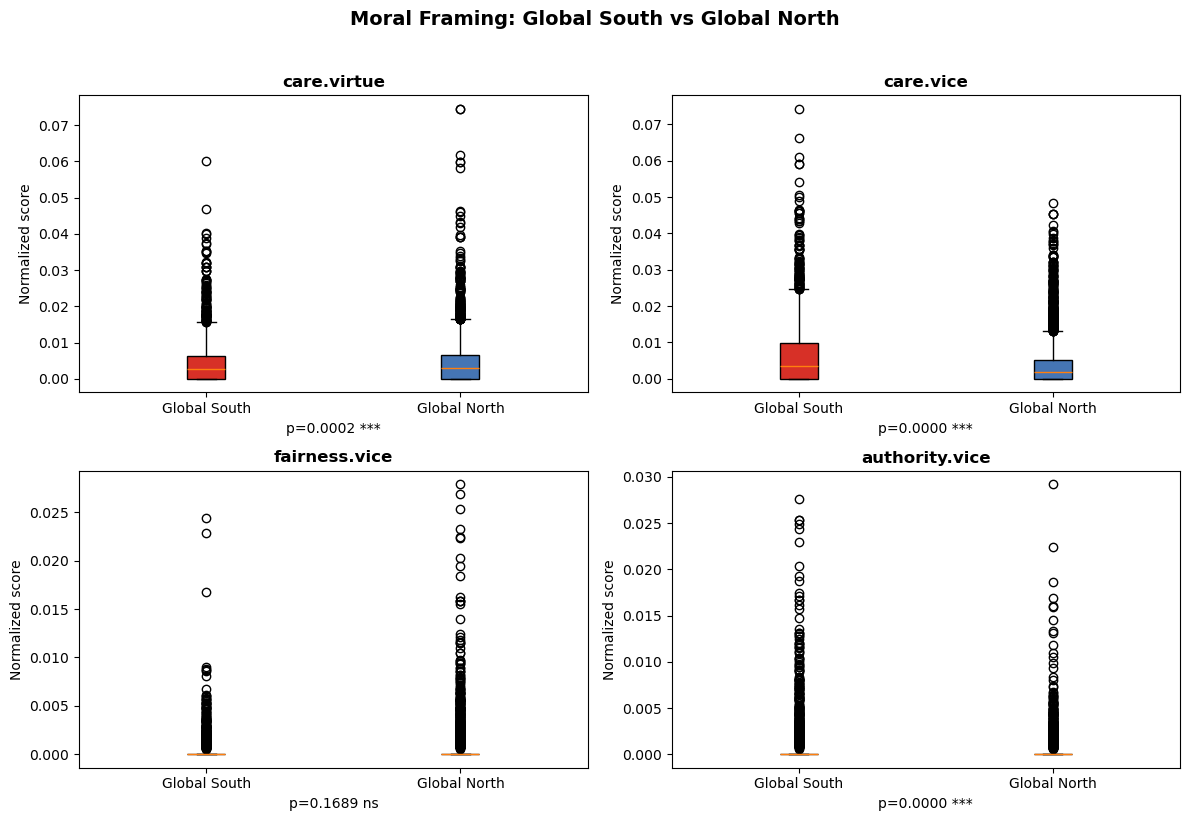

In [49]:
# ── 5. Boxplots — vice vs virtue across GN and GS ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = {'Global South': '#d73027', 'Global North': '#4575b4'}

for i, feature in enumerate(framing_features):
    ax = axes[i]
    
    data_to_plot = [
        south[feature].dropna(),
        north[feature].dropna()
    ]
    
    bp = ax.boxplot(data_to_plot, patch_artist=True, 
                    labels=['Global South', 'Global North'])
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('#d73027')
    bp['boxes'][1].set_facecolor('#4575b4')
    
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized score')
    
    # Add p-value annotation
    _, p = stats.mannwhitneyu(south[feature].dropna(), 
                               north[feature].dropna(), 
                               alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(f'p={p:.4f} {sig}', fontsize=10)

plt.suptitle('Moral Framing: Global South vs Global North', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

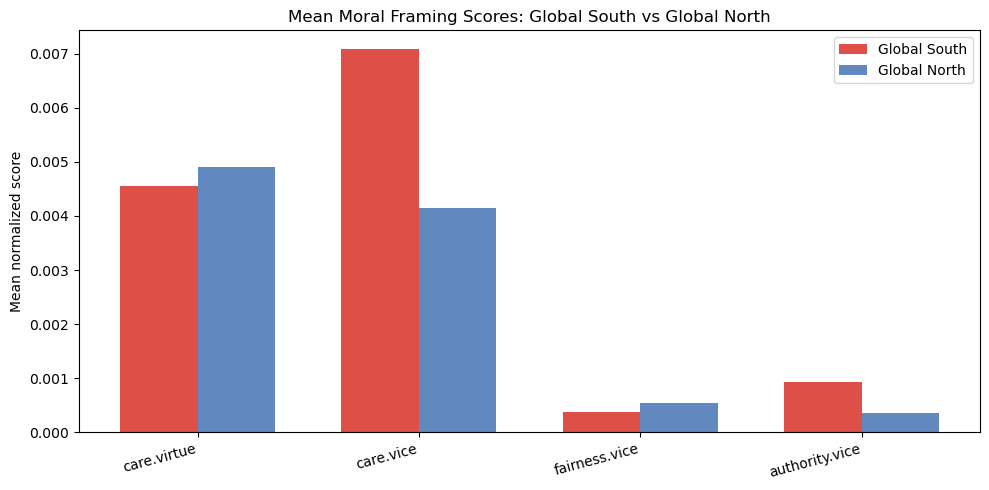

In [50]:
# ── 6. Bar chart of mean scores — easier to read for your paper ───────────
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(framing_features))
width = 0.35

gs_means = [south[f].mean() for f in framing_features]
gn_means = [north[f].mean() for f in framing_features]

bars1 = ax.bar([i - width/2 for i in x], gs_means, width, 
               label='Global South', color='#d73027', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], gn_means, width, 
               label='Global North', color='#4575b4', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(framing_features, rotation=15, ha='right')
ax.set_ylabel('Mean normalized score')
ax.set_title('Mean Moral Framing Scores: Global South vs Global North')
ax.legend()

plt.tight_layout()
plt.show()